In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_pickle("../data/processed/movies_clean.pkl")
df.shape

(1719, 13)

In [2]:
df.dtypes

movie_id                      int64
title                           str
overview                        str
release_date         datetime64[us]
runtime                     float64
original_language               str
genres                       object
keywords                     object
budget                      float64
revenue                     float64
popularity                  float64
vote_average                float64
vote_count                    int64
dtype: object

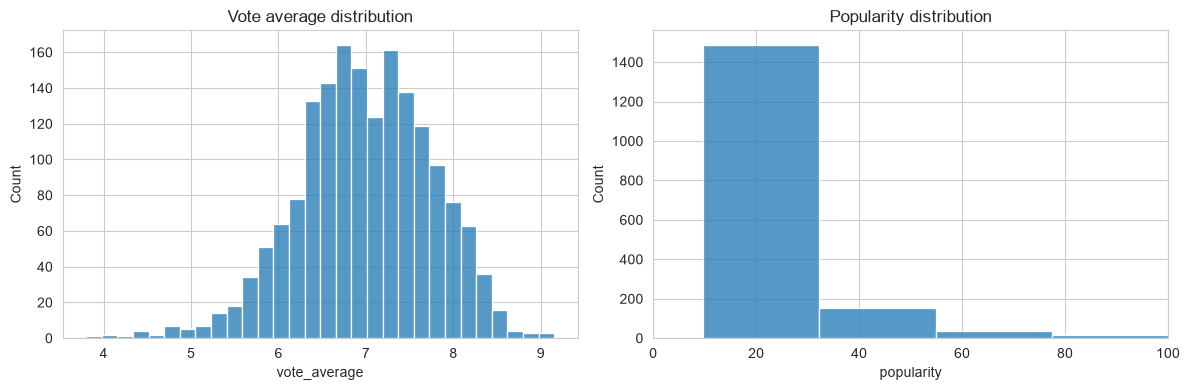

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["vote_average"], bins=30, ax=axes[0])
axes[0].set_title("Vote average distribution")
sns.histplot(df["popularity"], bins=30, ax=axes[1])
axes[1].set_title("Popularity distribution")
axes[1].set_xlim(0, 100)  # a few extreme outliers otherwise squash the chart
plt.tight_layout()
plt.show()

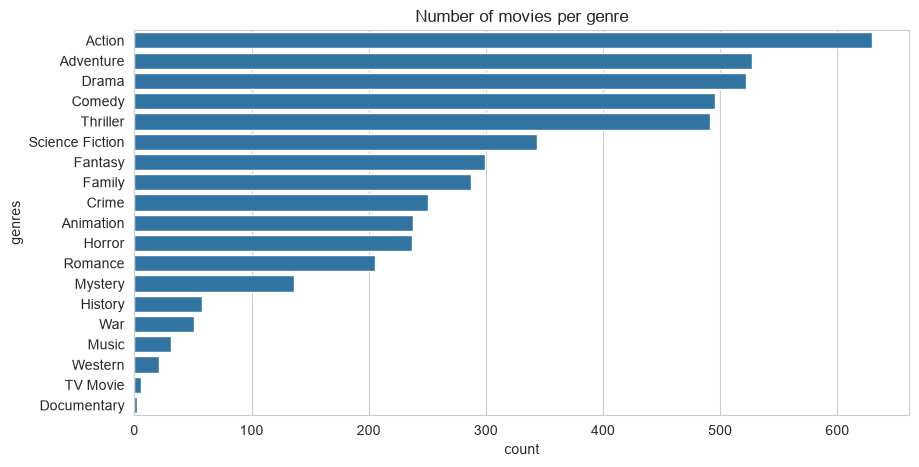

In [4]:
genre_counts = df.explode("genres")["genres"].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Number of movies per genre")
plt.xlabel("count")
plt.show()

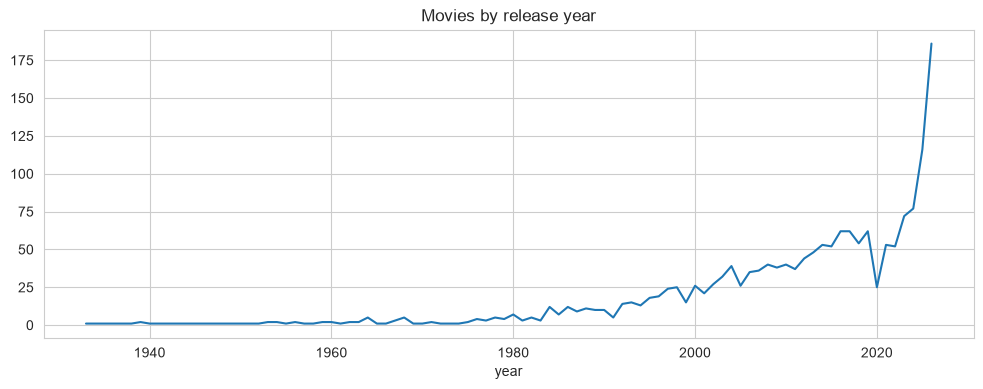

In [5]:
df["year"] = df["release_date"].dt.year
plt.figure(figsize=(12, 4))
df["year"].value_counts().sort_index().plot(kind="line")
plt.title("Movies by release year")
plt.show()

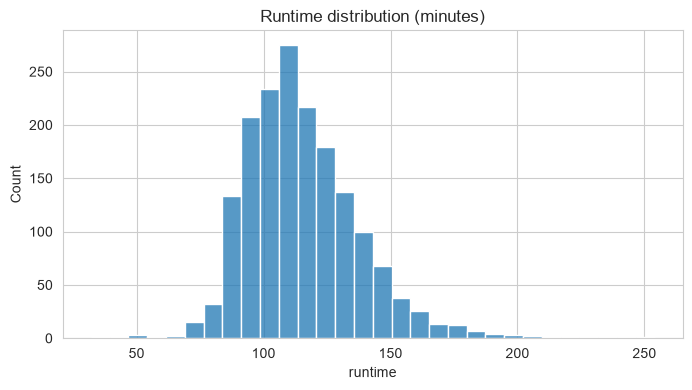

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(df["runtime"].dropna(), bins=30)
plt.title("Runtime distribution (minutes)")
plt.show()

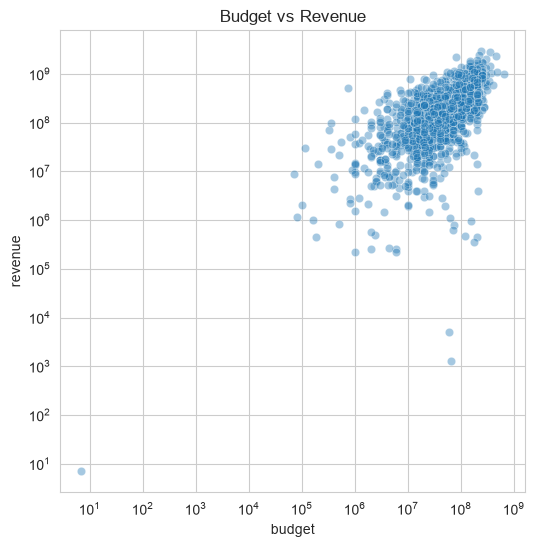

In [7]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x="budget", y="revenue", alpha=0.4)
plt.title("Budget vs Revenue")
plt.xscale("log")
plt.yscale("log")
plt.show()

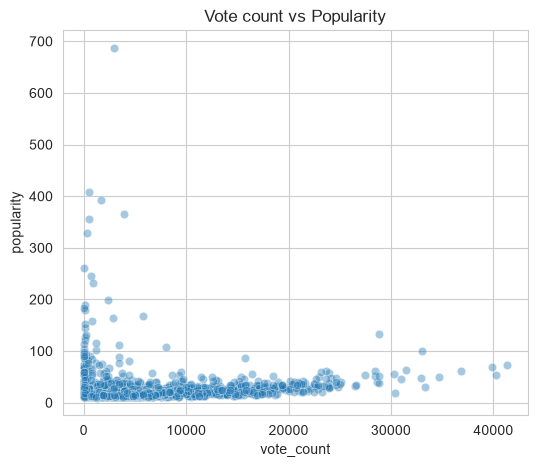

In [8]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="vote_count", y="popularity", alpha=0.4)
plt.title("Vote count vs Popularity")
plt.show()

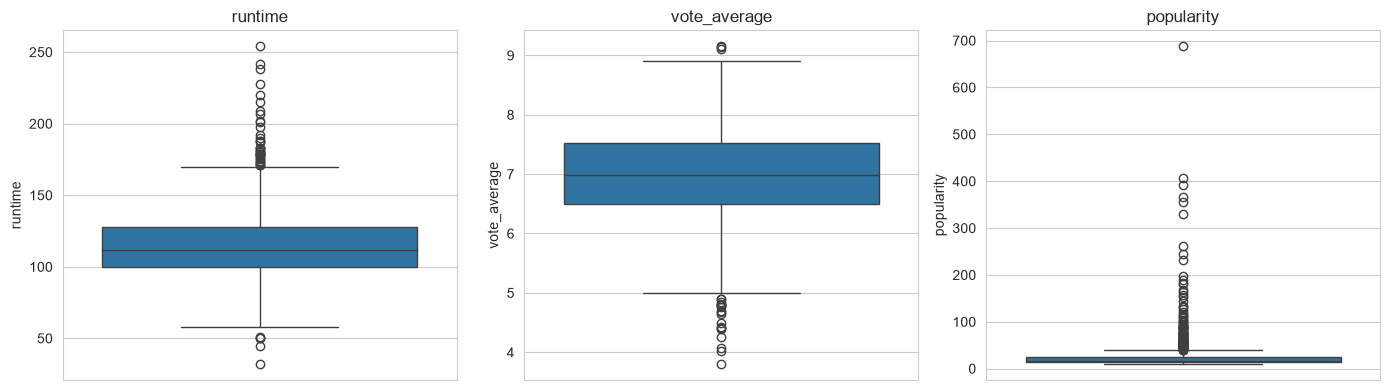

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["runtime", "vote_average", "popularity"]):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

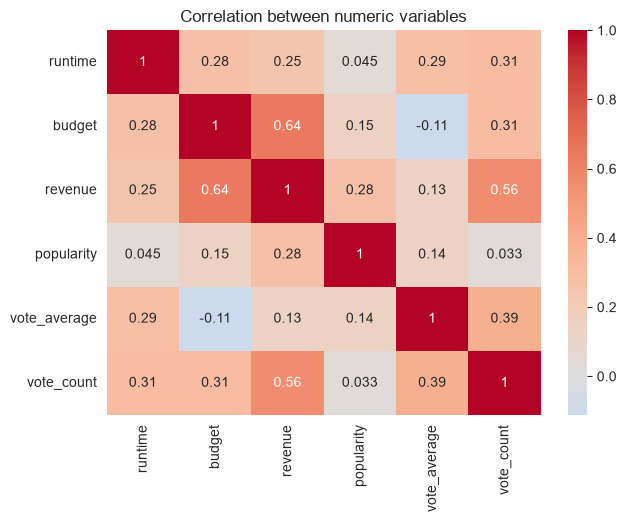

In [10]:
num_cols = ["runtime", "budget", "revenue", "popularity", "vote_average", "vote_count"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation between numeric variables")
plt.show()